#### Import numpy & keras

In [6]:
import numpy as np
import keras
from datasets import load_dataset, DatasetDict, Image, Dataset
import datetime

In [7]:
import tensorflow as tf
tf.config.optimizer.set_jit(False)
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

2.21.0
Num GPUs Available:  0
[]


### Bilder normalisieren

In [8]:
def transform(example):
    image = np.array(example["image"], dtype=np.float32) / 255.0
    return {"image": image, "label": example["label"]}


#### 1. get training data

In [9]:
import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

ds = load_dataset("jonathan-roberts1/NWPU-RESISC45")
print(ds.shape)

train_data = ds["train"]
split_1 = train_data.train_test_split(
    test_size=0.15,
    seed=42,          # sorgt dafür, dass Validation immer gleich bleibt
    shuffle=True
)

validation_dataset = split_1["test"]

12.2.0
{'train': (31500, 2)}


In [10]:
remaining_dataset = split_1["train"]
split_2 = remaining_dataset.train_test_split(
    test_size=0.25,
    shuffle=True
)

train_ds = split_2["train"]

In [11]:
from datasets import concatenate_datasets
import random

# -----------------------------
# AUGMENTER
# -----------------------------
augmenter = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.5),
    keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomContrast(0.15),
])

# -----------------------------
# AUGMENTATIONSANTEIL
# -----------------------------
augment_fraction = 0.2
num_augmented = int(len(train_ds) * augment_fraction)

indices = random.sample(range(len(train_ds)), num_augmented)
subset_to_augment = train_ds.select(indices)

# -----------------------------
# BATCH AUGMENTATION FUNKTION
# -----------------------------
def augment_batch(batch):
    images = np.array(batch["image"], dtype=np.float32)

    images = keras.ops.convert_to_tensor(images)
    images = augmenter(images, training=True)

    images = keras.ops.clip(images, 0, 255)
    images = keras.ops.convert_to_numpy(images).astype(np.uint8)

    return {
        "image": images,
        "label": np.array(batch["label"], dtype=np.int32)
    }

# -----------------------------
# MAP 
# -----------------------------
augmented_ds = subset_to_augment.map(
    augment_batch,
    batched=True,
    batch_size=32
)

# -----------------------------
# CONCATENATE
# -----------------------------
train_ds = concatenate_datasets([train_ds, augmented_ds])

# -----------------------------
# OUTPUT
# -----------------------------
print("Originale Trainingsdaten:", len(split_2["train"]))
print("Nach Augmentierung:", len(train_ds))

Map:   0%|          | 0/4016 [00:00<?, ? examples/s]

C:\Users\marie\AppData\Local\Programs\Python\Python312\Lib\site-packages\datasets\features\image.py:397: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Originale Trainingsdaten: 20081
Nach Augmentierung: 24097


In [12]:
from datasets import DatasetDict

test_ds = split_2["test"]

# DatasetDict erzeugen
final_dataset = DatasetDict({
    "train": train_ds,
    "validation": validation_dataset,
    "test": test_ds
})

# Optional nur falls image-feature kaputt ist
# from datasets import Image
# final_dataset = final_dataset.cast_column("image", Image())

# Transformation anwenden
final_dataset = final_dataset.with_transform(transform)

print(final_dataset)

# TensorFlow Datasets
tf_train = final_dataset["train"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=128,
    shuffle=True
)

tf_test = final_dataset["test"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=128
)

# Klassen
class_names = final_dataset["train"].features["label"].names
print(class_names)

# Bildform prüfen
img_shape = np.array(final_dataset["train"][0]["image"]).shape
print(img_shape)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 24097
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 6694
    })
})
['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud', 'commercial area', 'dense residential', 'desert', 'forest', 'freeway', 'golf course', 'ground track field', 'harbor', 'industrial area', 'intersection', 'island', 'lake', 'meadow', 'medium residential', 'mobile home park', 'mountain', 'overpass', 'palace', 'parking lot', 'railway', 'railway station', 'rectangular farmland', 'river', 'roundabout', 'runway', 'sea ice', 'ship', 'snowberg', 'sparse residential', 'stadium', 'storage tank', 'tennis court', 'terrace', 'thermal power station', 'wetland']
(256, 256, 3)


#### 2. define architecture

In [8]:
# Import a model from /models/*
## Todo: adjust modelname
from models.leNet_5 import generateModel
model_name = "leNet_5"

load model

In [9]:
#model = generateModel(img_shape)
model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 252, 252, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 126, 126, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 61, 61, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 4, 4, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │         5,805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,203,281 (4.59 MB)

 Trainable params: 401,093 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 802,188 (3.06 MB)

#### 3. set training parameter and fit model

# non-specific callbacks

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=40,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Epoch 1/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 289ms/step - accuracy: 0.6536 - loss: 1.2507 - val_accuracy: 0.3957 - val_loss: 2.2666 - learning_rate: 0.0010
Epoch 2/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 281ms/step - accuracy: 0.6995 - loss: 1.0846 - val_accuracy: 0.4101 - val_loss: 2.2541 - learning_rate: 0.0010
Epoch 3/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 279ms/step - accuracy: 0.7415 - loss: 0.9448 - val_accuracy: 0.4057 - val_loss: 2.2794 - learning_rate: 0.0010
Epoch 4/40
188/189 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7902 - loss: 0.7952
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
189/189 ━━━━━━━━━━━━━━━━━━━━ 54s 287ms/step - accuracy: 0.7747 - loss: 0.8332 - val_accuracy: 0.3996 - val_loss: 2.2940 - learning_rate: 0.0010
Epoch 5/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 280ms/step - accuracy: 0.8757 - loss: 0.5681 - val_accuracy: 0.4222 - val_loss: 2.2407 - learning_rate: 3.0000e-04
Epoch 6/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 54s 283ms/step - accuracy: 0

# Model 2 - four-block-cnn

In [12]:
## Todo: adjust modelname
from models.four_block_cnn import generateModel
model_name = "four_block_cnn"
#model = generateModel(img_shape)
model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=15,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,173,449 (12.11 MB)

 Trainable params: 1,057,325 (4.03 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 2,114,652 (8.07 MB)

Epoch 1/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7463 - loss: 0.8355 - val_accuracy: 0.6610 - val_loss: 1.2484 - learning_rate: 0.0010
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.7944 - loss: 0.6685 - val_accuracy: 0.6280 - val_loss: 1.4150 - learning_rate: 0.0010
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.8179 - loss: 0.5812 - val_accuracy: 0.6978 - val_loss: 1.0606 - learning_rate: 0.0010
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.8428 - loss: 0.5033 - val_accuracy: 0.7081 - val_loss: 1.0214 - learning_rate: 0.0010
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.8681 - loss: 0.4187 - val_accuracy: 0.6740 - val_loss: 1.2816 - learning_rate: 0.0010
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8948 - loss: 0.3328
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
189/189 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.8878 - loss: 0.348

# Model 3 - five_block_v1

In [13]:
## Todo: adjust modelname
from models.five_block_v1 import generateModel
model_name = "five_block_v1"
#model = generateModel(img_shape)
model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=20,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 40)   │        16,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 128, 128, 40)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 80)     │        28,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 32, 32, 80)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 160)    │       115,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 288)    │       415,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 288)    │         1,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 16, 288)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 288)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 288)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       110,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        17,325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,114,737 (8.07 MB)

 Trainable params: 704,693 (2.69 MB)

 Non-trainable params: 656 (2.56 KB)

 Optimizer params: 1,409,388 (5.38 MB)

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 151s 791ms/step - accuracy: 0.8399 - loss: 0.5038 - val_accuracy: 0.7788 - val_loss: 0.7498 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.8495 - loss: 0.4631
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
189/189 ━━━━━━━━━━━━━━━━━━━━ 149s 790ms/step - accuracy: 0.8498 - loss: 0.4644 - val_accuracy: 0.7468 - val_loss: 0.9171 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 149s 790ms/step - accuracy: 0.8902 - loss: 0.3395 - val_accuracy: 0.8288 - val_loss: 0.5647 - learning_rate: 3.0000e-04
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.8972 - loss: 0.3081
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
189/189 ━━━━━━━━━━━━━━━━━━━━ 149s 790ms/step - accuracy: 0.9003 - loss: 0.3040 - val_accuracy: 0.8419 - val_loss: 0.5236 - learning_rate: 3.0000e-04
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 149s 789ms/step - accu

# Model 4 - five_block_v2

In [16]:
## Todo: adjust modelname
from models.five_block_v2 import generateModel
model_name = "five_block_v2"
model = generateModel(img_shape)
#model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=20,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 24)   │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 96)   │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 192)  │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 192)  │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 128, 128, 192)  │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 256)  │       442,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 741,213 (2.83 MB)

 Trainable params: 740,541 (2.82 MB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 5002s 26s/step - accuracy: 0.1775 - loss: 3.2043 - val_accuracy: 0.0742 - val_loss: 4.7896 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 4895s 26s/step - accuracy: 0.3027 - loss: 2.5012 - val_accuracy: 0.1598 - val_loss: 3.6503 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 4339s 23s/step - accuracy: 0.3671 - loss: 2.2090 - val_accuracy: 0.3700 - val_loss: 2.2205 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 4575s 24s/step - accuracy: 0.3981 - loss: 2.0851 - val_accuracy: 0.3059 - val_loss: 2.4266 - learning_rate: 0.0010
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.4315 - loss: 1.9606 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
189/189 ━━━━━━━━━━━━━━━━━━━━ 4394s 23s/step - accuracy: 0.4378 - loss: 1.9325 - val_accuracy: 0.3068 - val_loss: 2.5905 - learning_rate: 0.0010
Epoch 6/20
 73/189 ━━━━━━━━━━━━━━━━━━━━ 1:15:44 39s/step - accuracy: 0.47

KeyboardInterrupt: 

In [17]:
model.save(savepath)

# Model 5 - resNet

In [15]:
## Todo: adjust modelname


from models.resNet import generateModel
model_name = "resNet"
#model = generateModel(img_shape)
model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=5,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_58[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_32[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_59[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 256, 256,  │          0 │ add_16[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_33[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_34[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_33[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 256, 256,  │          0 │ add_17[0][0]    

 Total params: 2,879,599 (10.98 MB)

 Trainable params: 2,874,797 (10.97 MB)

 Non-trainable params: 4,800 (18.75 KB)

 Optimizer params: 2 (12.00 B)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 2566s 14s/step - accuracy: 0.2854 - loss: 2.5800 - val_accuracy: 0.0865 - val_loss: 19.6809 - learning_rate: 0.0010
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3759 - loss: 2.1915 
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
189/189 ━━━━━━━━━━━━━━━━━━━━ 2550s 13s/step - accuracy: 0.3908 - loss: 2.1291 - val_accuracy: 0.2604 - val_loss: 3.2745 - learning_rate: 0.0010
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 2548s 13s/step - accuracy: 0.4878 - loss: 1.7504 - val_accuracy: 0.3463 - val_loss: 2.2870 - learning_rate: 3.0000e-04
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5194 - loss: 1.6317 
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
189/189 ━━━━━━━━━━━━━━━━━━━━ 2549s 13s/step - accuracy: 0.5265 - loss: 1.6100 - val_accuracy: 0.4948 - val_loss: 1.7319 - learning_rate: 3.0000e-04
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 2550s 13s/step - accuracy: 0.573

In [4]:
#%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 33128), started 5 days, 22:58:25 ago. (Use '!kill 33128' to kill it.)

#### 4. predict output 

Index: 3655
Predicted: snowberg
True: mountain


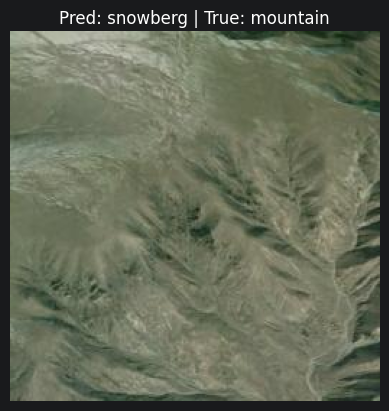

In [17]:
import random

# Zufälligen Index wählen
idx = random.randint(0, len(final_dataset["test"]) - 1)

# Sample holen
sample = final_dataset["test"][idx]

# Bild und echtes Label
img = sample["image"]
true_idx = sample["label"]

# Batch-Dimension hinzufügen
input_img = np.expand_dims(img, axis=0)

# Prediction
prediction = model.predict(input_img, verbose=0)

# Vorhersageklasse
predicted_idx = np.argmax(prediction)

# Ausgabe
print("Index:", idx)
print("Predicted:", class_names[predicted_idx])
print("True:", class_names[true_idx])

# Bild anzeigen
plt.imshow(img)
plt.title(f"Pred: {class_names[predicted_idx]} | True: {class_names[true_idx]}")
plt.axis("off")
plt.show()

# All summaries

In [7]:
leNet = keras.models.load_model("./models/leNet_5.keras")
leNet.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 252, 252, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 126, 126, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 61, 61, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 4, 4, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │         5,805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,203,281 (4.59 MB)

 Trainable params: 401,093 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 802,188 (3.06 MB)

In [9]:
fourBlock = keras.models.load_model("./models/four_block_cnn.keras")
fourBlock.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,173,449 (12.11 MB)

 Trainable params: 1,057,325 (4.03 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 2,114,652 (8.07 MB)

In [10]:
fiveBlock1 = keras.models.load_model("./models/five_block_v1.keras")
fiveBlock1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 40)   │        16,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 128, 128, 40)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 80)     │        28,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 32, 32, 80)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 160)    │       115,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 288)    │       415,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 288)    │         1,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 16, 288)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 288)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 288)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       110,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        17,325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,114,737 (8.07 MB)

 Trainable params: 704,693 (2.69 MB)

 Non-trainable params: 656 (2.56 KB)

 Optimizer params: 1,409,388 (5.38 MB)

In [11]:
fiveBlock2 = keras.models.load_model("./models/five_block_v2.keras")
fiveBlock2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 24)   │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 96)   │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 192)  │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 192)  │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 128, 128, 192)  │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 256)  │       442,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,222,297 (8.48 MB)

 Trainable params: 740,541 (2.82 MB)

 Non-trainable params: 672 (2.62 KB)

 Optimizer params: 1,481,084 (5.65 MB)

In [12]:
resNet = keras.models.load_model("./models/resNet.keras")
resNet.summary()

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_58[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_32[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_59[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 256, 256,  │          0 │ add_16[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_33[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_34[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_33[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 256, 256,  │          0 │ add_17[0][0]    

 Total params: 8,629,193 (32.92 MB)

 Trainable params: 2,874,797 (10.97 MB)

 Non-trainable params: 4,800 (18.75 KB)

 Optimizer params: 5,749,596 (21.93 MB)